In [11]:
import requests
import datetime
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [12]:
def query_range_prometheus(query, start, end, step, endpoint="http://prometheus:9090"):
    url = f"{endpoint}/api/v1/query_range"
    params = {
        'query': query,
        'start': start,
        'end': end,
        'step': step
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        result = response.json()
        if result.get("status") == "success":
            return result["data"]["result"]
        else:
            print(f"Error: {result}")
            return None
    except requests.exceptions.RequestException as e:
        print(f"Error '{query}': {e}")
        return None

In [13]:
def collect_metrics(time_window_seconds=300, step=30):
    tz_sp = ZoneInfo("America/Sao_Paulo")
    end_time = datetime.datetime.now(tz_sp)
    start_time = end_time - datetime.timedelta(seconds=time_window_seconds)
    start_ts = start_time.timestamp()
    end_ts = end_time.timestamp()
    
    metrics = {
        "produced_messages": "kafka_messages_produced_total",
        "consumed_messages": "kafka_messages_consumed_total",
        "dlq_messages":      "kafka_topic_dead_letter_queue_messages_produced_total",
        "active_connections": "kafka_stream_data_active_connections",
        "devices_connected": "kafka_topic_devices_messages_consumed_total"
    }
    
    collected = {}
    for key, query in metrics.items():
        data = query_range_prometheus(query, start=start_ts, end=end_ts, step=step)
        if data and len(data) > 0:
            values = data[0].get("values", [])
            parsed_values = []
            for ts_str, value_str in values:
                ts = datetime.datetime.fromtimestamp(float(ts_str), tz=tz_sp)
                try:
                    value = float(value_str)
                except ValueError:
                    value = None
                parsed_values.append((ts, value))
            collected[key] = parsed_values
        else:
            collected[key] = []
    return collected

In [14]:
def merge_metrics(collected):
    merged_df = None
    for key, data in collected.items():
        df = pd.DataFrame(data, columns=["timestamp", key])
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on="timestamp", how="outer")
    
    merged_df.sort_values("timestamp", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    # Converte as colunas (exceto "timestamp") para numérico para evitar FutureWarnings
    for col in merged_df.columns:
        if col != "timestamp":
            merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')
    
    # Interpola e preenche valores ausentes
    merged_df.interpolate(method="linear", inplace=True)
    merged_df.fillna(0, inplace=True)
    return merged_df

In [15]:
def analyze_merged_df(df):
    if "produced_messages" in df.columns:
        df["delta_produced"] = df["produced_messages"].diff()
    if "consumed_messages" in df.columns:
        df["delta_consumed"] = df["consumed_messages"].diff()
    if "dlq_messages" in df.columns:
        df["delta_dlq"] = df["dlq_messages"].diff()
        # Marca como erro se houver aumento (delta positivo) na DLQ
        df["error_occurred"] = df["delta_dlq"].apply(lambda x: True if pd.notnull(x) and x > 0 else False)
    if "produced_messages" in df.columns and "consumed_messages" in df.columns:
        df["ratio"] = df.apply(lambda row: (row["consumed_messages"] / row["produced_messages"])
                               if row["produced_messages"] and row["produced_messages"] != 0 else None, axis=1)
    return df

In [16]:
def plot_metrics(df):
    plt.figure(figsize=(12, 10))
    tz_display = ZoneInfo("America/Sao_Paulo")
    locator = mdates.MinuteLocator(interval=1)
    formatter = mdates.DateFormatter("%H:%M:%S", tz=tz_display)
    
    # Subplot 1: Mensagens produzidas e consumidas
    plt.subplot(2, 2, 1)
    if "produced_messages" in df.columns and "consumed_messages" in df.columns:
        plt.plot(df["timestamp"], df["produced_messages"], marker="o", label="Produzidas")
        plt.plot(df["timestamp"], df["consumed_messages"], marker="o", label="Consumidas")
        plt.title("Total de Mensagens Produzidas x Consumidas")
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        ax = plt.gca()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
    
    # Subplot 2: DLQ
    plt.subplot(2, 2, 2)
    if "delta_dlq" in df.columns:
        plt.plot(df["timestamp"], df["delta_dlq"], marker="o", color="red", label="DLQ")
        plt.title("Total de mensagens com erro")
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.ylim(0)
        max_value_dlq = df["delta_dlq"].max()
        if pd.notnull(max_value_dlq):
            plt.yticks(range(0, int(max_value_dlq) + 4))
        else:
            plt.yticks(range(0, 5))
        ax = plt.gca()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
    
    # Subplot 3: Conexões ativas
    plt.subplot(2, 2, 3)
    if "active_connections" in df.columns:
        plt.plot(df["timestamp"], df["active_connections"], marker="o", color="purple")
        plt.title("Quantidade de Conexões Ativas")
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.ylim(0)
        max_value_connections = df["active_connections"].max()
        if pd.notnull(max_value_connections):
            plt.yticks(range(0, int(max_value_connections) + 4))
        else:
            plt.yticks(range(0, 5))
        ax = plt.gca()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
    
    # Subplot 4: Dispositivos de monitoramento de dados vitais
    plt.subplot(2, 2, 4)
    if "devices_connected" in df.columns:
        plt.plot(df["timestamp"], df["devices_connected"], marker="o", color="green", label="Dispositivos")
        plt.title("Quantidade de Dispositivos de Monitoramento de Dados Vitais")
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        ax = plt.gca()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        max_devices = df["devices_connected"].max()
        if pd.notnull(max_devices):
            ax.set_yticks(range(0, int(max_devices) + 4))
        else:
            ax.set_yticks(range(0, 5))

    plt.tight_layout()
    plt.show()

In [17]:
def display_results():
    # Coleta as métricas em um período de 5 minutos (300 segundos) com amostragem a cada 30 segundos
    collected = collect_metrics(time_window_seconds=300, step=30)
    df = merge_metrics(collected)
    df = analyze_merged_df(df)
    
    # Converte as colunas para inteiro e preenche NaN com 0
    int_columns = ['produced_messages', 'consumed_messages', 'active_connections',
                   'dlq_messages', 'delta_produced', 'delta_consumed', 'delta_dlq', 'devices_connected']
    for col in int_columns:
        if col in df.columns:
            df[col] = df[col].fillna(0).round(0).astype(int)
    
    tz_sp = ZoneInfo("America/Sao_Paulo")
    now = datetime.datetime.now(tz_sp).isoformat()
    print(f"\nResultados de teste na data: {now}:\n")
    print(df)
    
    if "delta_produced" in df.columns and "delta_consumed" in df.columns:
        avg_delta_produced = df["delta_produced"].mean()
        avg_delta_consumed = df["delta_consumed"].mean()
        print(f"\nMédia delta produzido: {avg_delta_produced:.2f}")
        print(f"Média delta consumido: {avg_delta_consumed:.2f}")
    if "ratio" in df.columns:
        avg_ratio = df["ratio"].mean()
        print(f"Média entre consumidas/produzidas: {avg_ratio:.2f}")
    if "delta_dlq" in df.columns:
        total_dlq_increase = df["delta_dlq"].sum(skipna=True)
        print(f"Total de mensagens na DLQ: {total_dlq_increase}")
    
    plot_metrics(df)


Resultados de teste na data: 2025-04-21T18:39:20.167480-03:00:

                          timestamp  produced_messages  consumed_messages  \
0  2025-04-21 18:34:20.126000-03:00                141                127   
1  2025-04-21 18:34:50.126000-03:00                261                247   
2  2025-04-21 18:35:20.126000-03:00                383                367   
3  2025-04-21 18:35:50.126000-03:00                624                595   
4  2025-04-21 18:36:20.126000-03:00                925                892   
5  2025-04-21 18:36:50.126000-03:00               1232               1192   
6  2025-04-21 18:37:20.126000-03:00               1653               1606   
7  2025-04-21 18:37:50.126000-03:00               2097               2026   
8  2025-04-21 18:38:20.126000-03:00               2755               2681   
9  2025-04-21 18:38:50.126000-03:00               3415               3340   
10 2025-04-21 18:39:20.126000-03:00               4075               4000   

    dlq_me

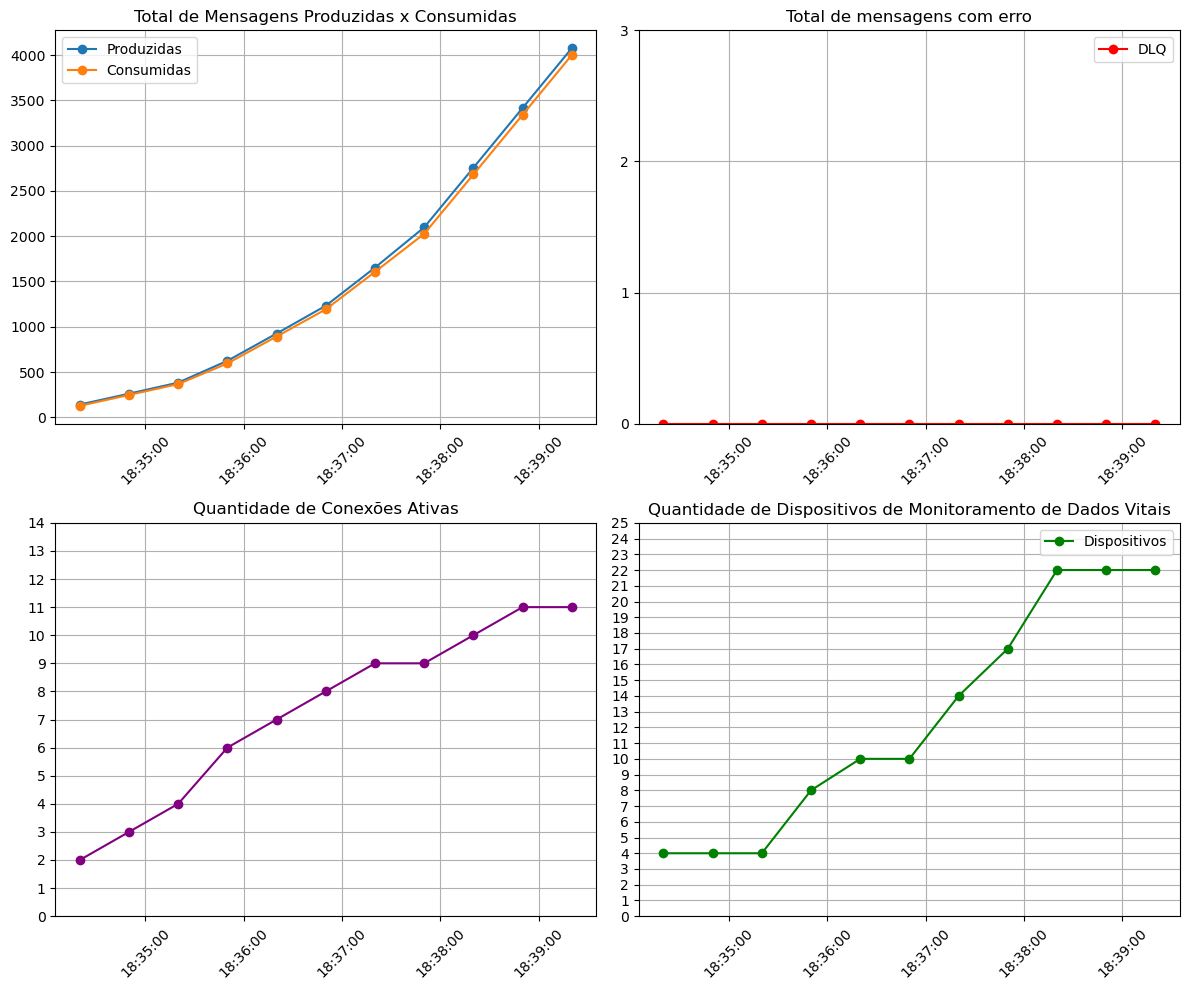

In [29]:
display_results()